# EDA y KPIs - Servicio Ciudadano 1800 (Caso 15)
Este cuaderno fue adaptado para cargar la vista limpia y responder a las preguntas de negocio (KPIs).

In [1]:
import os
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Conexión directa a SQL Server (contenedor db)
server = os.getenv('DB_SERVER', 'db')
database = os.getenv('DB_NAME', 'ServicioCiudadanoDW')
username = os.getenv('DB_USER', 'SA')
password = os.getenv('DB_PASSWORD', 'J0AhMXX4H0QBrRr8R1U098y8aA1@')
driver = os.getenv('DB_DRIVER', '{ODBC Driver 18 for SQL Server}')

connection_string = f'DRIVER={driver};SERVER={server};DATABASE={database};UID={username};PWD={password};TrustServerCertificate=yes;'

print("🔄 Conectando a SQL Server y cargando datos...")
conn = pyodbc.connect(connection_string)
df = pd.read_sql("SELECT * FROM vw_v1_limpio", conn)
conn.close()

print(f"✅ Datos cargados: {df.shape[0]} filas limpias, {df.shape[1]} columnas")
df.head()


🔄 Conectando a SQL Server y cargando datos...


/tmp/ipykernel_120/328054759.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM vw_v1_limpio", conn)


✅ Datos cargados: 73923 filas limpias, 14 columnas


,id_interaccion,fecha_contacto,fecha_carga,canal,motivo_contacto,cola_servicio,duracion_seg,espera_seg,grabacion_autorizada,recontacto_7_dias,casos_previos_30d,nivel_transferencias,tipo_usuario,turno
0,0001d351-20eb-41bb-9428-4bfb5e43b418,2025-12-03 20:14:51.547,2026-10-07 21:14:51.543,Web,Falla,Información,637,56,No,1,0,0,Gobierno,Nocturno
1,00026c98-43fe-4fea-84ac-9d999163fd97,2026-09-15 18:16:39.993,2026-10-07 21:16:39.990,Teléfono,Cobro,Reclamos,815,773,Sí,0,0,0,Particular,PM
2,00033b0e-9a6e-463d-a334-b9f0d8ede7b6,2026-09-14 17:21:54.507,2026-10-07 21:21:54.503,Web,Cobro,Reclamos,598,641,Sí,0,2,2,Particular,PM
3,000cc91e-7dc4-4c0e-8a1b-361d529b7857,2026-03-25 09:16:51.693,2026-10-07 21:16:51.687,Teléfono,Queja,Reclamos,990,759,Sí,0,0,0,Empresa,AM
4,000f7e48-851d-42bd-bcab-dc3b1e0b4b35,2026-05-29 23:15:05.893,2026-10-07 21:15:05.890,App,Consulta,Reclamos,177,551,No,0,0,0,Particular,Nocturno


🎯 KPI 1: Tasa de Recontacto a 7 días (TR7)
   Valor Actual: 40.21% (Meta del negocio: <= 22%)
------------------------------------------------------------
🏆 KPI 2: FCR Estimado (First Contact Resolution)
   Valor Actual: 59.79% (Benchmark sector: >= 78%)


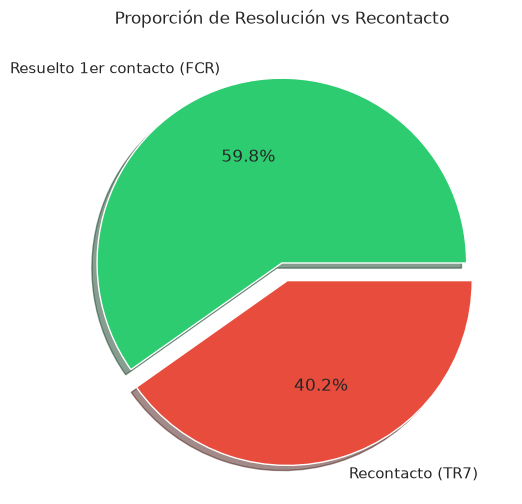

In [2]:
# Celda 2: KPI 1 & 2 - Tasa de Recontacto (TR7) y FCR Estimado
# El recontacto es nuestra variable objetivo principal
tr7 = df['recontacto_7_dias'].mean() * 100
fcr = 100 - tr7

print("=" * 60)
print(f"🎯 KPI 1: Tasa de Recontacto a 7 días (TR7)")
print(f"   Valor Actual: {tr7:.2f}% (Meta del negocio: <= 22%)")
print("-" * 60)
print(f"🏆 KPI 2: FCR Estimado (First Contact Resolution)")
print(f"   Valor Actual: {fcr:.2f}% (Benchmark sector: >= 78%)")
print("=" * 60)

# Gráfico de pastel
plt.figure(figsize=(6,6))
plt.pie([fcr, tr7], labels=['Resuelto 1er contacto (FCR)', 'Recontacto (TR7)'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1), shadow=True)
plt.title('Proporción de Resolución vs Recontacto')
plt.show()


/tmp/ipykernel_120/2891299340.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='canal', y='recontacto_7_dias', ax=axes[0], palette='viridis', errorbar=None)
/tmp/ipykernel_120/2891299340.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='motivo_contacto', y='recontacto_7_dias', ax=axes[1], palette='magma', errorbar=None)
/tmp/ipykernel_120/2891299340.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='cola_servicio', y='recontacto_7_dias', ax=axes[2], palette='coolwarm', errorbar=None)


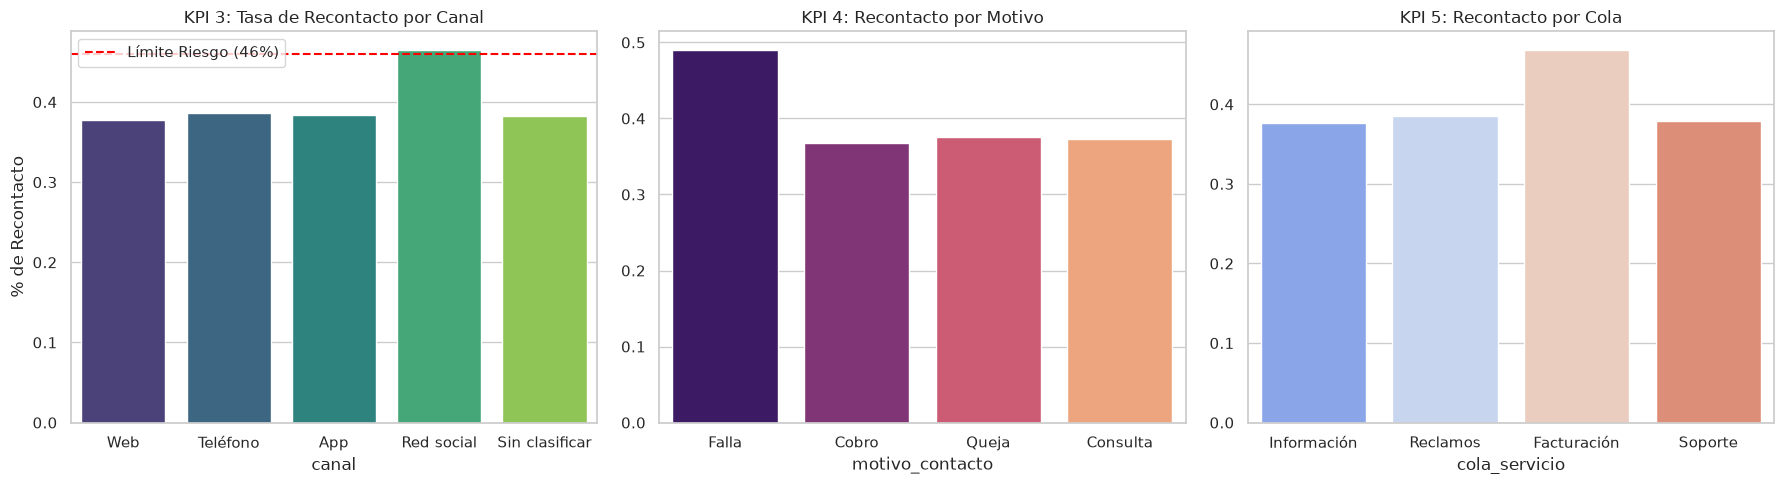

In [3]:
# Celda 3: KPI 3, 4 y 5 - Riesgo de Recontacto por Dimensiones
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Por Canal
sns.barplot(data=df, x='canal', y='recontacto_7_dias', ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('KPI 3: Tasa de Recontacto por Canal', fontsize=14, fontweight='bold')
axes[0].set_ylabel('% de Recontacto')
axes[0].axhline(0.46, color='red', linestyle='--', label='Límite Riesgo (46%)')
axes[0].legend()

# Por Motivo
sns.barplot(data=df, x='motivo_contacto', y='recontacto_7_dias', ax=axes[1], palette='magma', errorbar=None)
axes[1].set_title('KPI 4: Recontacto por Motivo', fontsize=14, fontweight='bold')
axes[1].set_ylabel('% de Recontacto')

# Por Cola
sns.barplot(data=df, x='cola_servicio', y='recontacto_7_dias', ax=axes[2], palette='coolwarm', errorbar=None)
axes[2].set_title('KPI 5: Recontacto por Cola', fontsize=14, fontweight='bold')
axes[2].set_ylabel('% de Recontacto')

plt.tight_layout()
plt.show()
